# Challenge: Absolute Error Bound over Spatial Gradient

You are challenged to find a compressor that produces the highest compression ratio when compressing the provided specific humidity example dataset with an absolute error bound over the gradient along the periodic longitude axis. The compressor must not violate the error bound.

This product includes software produced by UChicago Argonne, LLC under Contract No. DE-AC02-06CH11357 with the Department of Energy.

In [1]:
from pathlib import Path

import netCDF4
import numpy as np
import xarray as xr

In [2]:
data = Path("data")

In [3]:
import earthkit.plots

from quickplot import quickplot

## Challenge Configuration (do not edit)

In [4]:
# Load the data
ds = xr.open_dataset(
    data / "NextGEMS_EW3_ICON_ngc4008" / "NextGEMS_regridded_hus_025deg_steps_44_45.nc",
    engine="netcdf4",
    decode_timedelta=True,
)
da = ds["hus"]

In [5]:
eb_abs_qoi_check = 1e-6

## Compressor Configuration (edit here)

In [6]:
psnr = 25  # dB

In [7]:
from numcodecs_wasm_sperr import Sperr

codec = Sperr(mode="psnr", psnr=psnr)

## Challenge Evaluation (do not edit)

In [8]:
# encode and decode the data
da_enc = codec.encode(da.values)
da_dec = da.copy(data=codec.decode(da_enc))

In [9]:
def differentiate_along_longitude(da: xr.DataArray) -> xr.DataArray:
    # dX / dlon = (x[i+5] - x[i-5]) / ((lon[i+5] - lon[i-5]) % 360)
    da_dXdLon = (da.roll(lon=5) - da.roll(lon=-5)) / (
        np.mod(da.lon.roll(lon=5) - da.lon.roll(lon=-5), 360)
    )
    da_dXdLon.attrs.update(
        long_name=f"{da.long_name} derivative along longitude",
        units=(f"{da.units} degree**-1" if hasattr(da, "units") else "degree**-1"),
    )
    return da_dXdLon

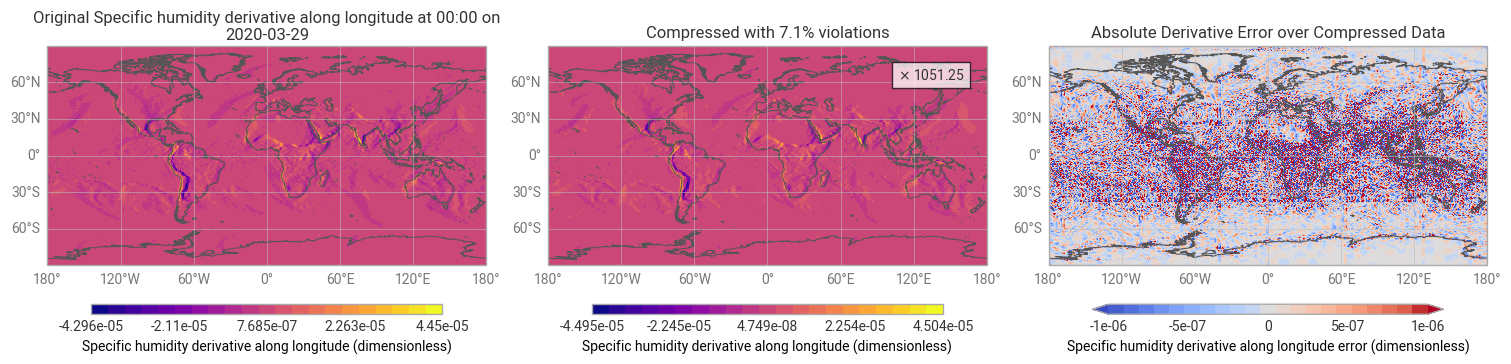

In [10]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    size=(15, 4),
    rows=1,
    columns=3,
)

da_deriv = differentiate_along_longitude(da)
da_dec_deriv = differentiate_along_longitude(da_dec)

# violation if
# (a) the absolute error bound over the derivative is exceeded
violations = np.mean(~((da_dec_deriv - da_deriv) <= eb_abs_qoi_check))
violations = (
    0
    if violations == 0
    else np.format_float_positional(100 * violations, precision=1, min_digits=1) + "%"
)
if violations == "0.0%":
    violations = "<0.05%"

quickplot(da_deriv, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec_deriv,
    fig.add_map(0, 1),
    title=f"Compressed with {violations} violations",
    cr=da.nbytes / np.array(da_enc).nbytes,
)
quickplot(
    (da_dec_deriv - da_deriv).assign_attrs(long_name=f"{da_deriv.long_name} error"),
    fig.add_map(0, 2),
    error=True,
    vrange=(-eb_abs_qoi_check, eb_abs_qoi_check),
    title="Absolute Derivative Error over Compressed Data",
)

fig.show()